### EXAMEN - Convocatoria 1 - Programación
Utilizar el conjunto de datos "dataset_exam.npy" para resolver el ejercicio. Tener en cuenta que la última columna corresponde a la clase.

In [79]:
#Imports
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import preprocessing, svm
from sklearn.feature_selection import SelectPercentile
from sklearn.feature_selection import f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_score
import sklearn.metrics as metrics

#### 1) Partición de datos externa (1 punto)
Realizar una partición externa de tipo hold-out seleccionando un 20% de los datos para test (fijar una semilla en 42).
Comprobad si los datos, tanto de train como de test, están más o menos balanceados.

In [80]:
# Cargamos los datos 
data = np.load('dataset_exam.npy', allow_pickle=True)
X = data[:, :-1] # todas las filas, todas las columnas menos la última
y = data[:, -1] # todas las filas, solo la última columna
X_training, X_testing, y_training, y_testing = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # hold-out de 20%, semilla 42, estratificado; visto en tema 4

In [81]:
#Validar que los datos estan balanceados entre train y test, representado como enteros
print("Número de muestras en el conjunto de entrenamiento:", X_training.shape[0])
print("Distribución de clases en el conjunto de entrenamiento:")
print("Muestras clase 0:", np.sum(y_training == 0))
print("Muestras clase 1:", np.sum(y_training == 1))
print("Número de muestras en el conjunto de prueba:", X_testing.shape[0])
print("Distribución de clases en el conjunto de prueba:")
print("Muestras clase 0:", np.sum(y_testing == 0))
print("Muestras clase 1:", np.sum(y_testing == 1))


Número de muestras en el conjunto de entrenamiento: 393
Distribución de clases en el conjunto de entrenamiento:
Muestras clase 0: 196
Muestras clase 1: 197
Número de muestras en el conjunto de prueba: 99
Distribución de clases en el conjunto de prueba:
Muestras clase 0: 50
Muestras clase 1: 49


#### 2) Estandarización de los datos de train y test (1 punto)
Utilizar el método StandardScaler().

In [82]:
#Estandarización de los datos de entrenamiento
scaler = preprocessing.StandardScaler()
X_train_stdr = scaler.fit_transform(X_training)
X_test_stdr = scaler.transform(X_testing)

#### 3) Selección de atributos en train y test (1 punto)
Aplicar el método de mutual information para clasificación seleccionando un percentile=90. (Recordad la función "SelectPercentile")

In [83]:
#Selección de características
selector = SelectPercentile(score_func=f_classif, percentile=90) #Seleccionar el 90% de las características basadas en F-value entre etiquetas y características
X_train_selected = selector.fit_transform(X_train_stdr, y_training)
X_test_selected = selector.transform(X_test_stdr)
print("Número de características después de la selección:", X_train_selected.shape[1])
print(np.shape(X_train_selected))

Número de características después de la selección: 7
(393, 7)


#### 4) Comparación de modelos de clasificación mediante validación cruzada (3 puntos)
Instrucciones:

- Aplicar una validación cruzada interna de K=5 bolsas para optimizar y comparar la capacidad predictiva de los siguientes modelos: Regresión Logística y Support Vector Machine.
- La optimización de hiperparámetros debe realizarse de manera automática. (Recordad la función "GridSearchCV").
- La comparación debe realizarse únicamente en términos de exactitud proporcionando resultados de media +- desviación estándar.

In [84]:
# Modelos a evaluar
algoritmos = { 'LOGR': LogisticRegression(C=10, random_state=42, max_iter=1000),'SVM': svm.SVC(C=10, random_state=42, probability=True)}
param_grid = { # Hiperparámetros a optimizar, diferentes para cada modelo
    'LOGR': {'C': [0.1, 1, 10], 'penalty': ['l2'], 'solver': ['lbfgs', 'saga']},
    'SVM': {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
}

In [85]:
# Modelos a evaluar
# Regresion Logistica, K=5, validacion cruzada, GridSearchCV
print("Algoritmos a evaluar:", algoritmos.keys())
for nombre, alg in algoritmos.items():
    grid_search = GridSearchCV(alg, param_grid[nombre], cv=5, scoring='accuracy') # 5-fold (bolsas) cross-validation
    grid_search.fit(X_train_selected, y_training)
    scores = cross_val_score(grid_search.best_estimator_, X_train_selected, y_training, cv=5, scoring='accuracy') # Evaluar con validación cruzada usando el mejor estimador encontrado
    print(f"{nombre}: Exactitud media: {scores.mean():.4f}, Desviación estándar: {scores.std():.4f}")


Algoritmos a evaluar: dict_keys(['LOGR', 'SVM'])
LOGR: Exactitud media: 0.7174, Desviación estándar: 0.0329
SVM: Exactitud media: 0.8093, Desviación estándar: 0.0341


#### 5) Evaluación de los modelos sobre el conjunto de test (2.5 puntos)
- Entrenar los modelos anteriores utilizando todos los datos de entrenamiento.
- Evaluar su rendimiento sobre el conjunto de test mostrando una tabla de resultados tal que:
 * Las filas serán: Precisión, Sensibilidad, F-score, Exactitud y AUC
 * Las columnas serán: LOGR y SVM

In [72]:
# Entrenar los modelos sobre el conjunto de entrenamiento completo y evaluarlos en el conjunto de prueba
models = {}
for nombre, alg in algoritmos.items():
    grid_search = GridSearchCV(alg, param_grid[nombre], cv=5, scoring='accuracy')
    grid_search.fit(X_train_selected, y_training)
    models[nombre] = grid_search.best_estimator_

# Evaluar en el conjunto de prueba
y_pred_test = {}
for nombre, model in models.items():
    y_pred_test[nombre] = model.predict(X_test_selected)

# Calculo de las metricas de evaluacion en el conjunto de prueba en formato de tabla donde Las filas son: Precisión, Sensibilidad, F-score, Exactitud y AUC y Las columnas serán: LOGR y SVM
metricas = ['Precision', 'Sensibilidad', 'F-Score', 'Exactitud', 'AUC']
# Representacion en formato de tabla donde las filas son las métricas y las columnas los modelos
print("\nTabla resumen de métricas:")
header = "Métrica".ljust(15) + "".join([nombre.ljust(15) for nombre in algoritmos.keys()])
print(header)
for metrica in metricas:
    row = metrica.ljust(15)
    for nombre in algoritmos.keys():
        y_pred = y_pred_test[nombre]
        if metrica == 'Precision':
            value = metrics.precision_score(y_testing, y_pred, average='weighted')
        elif metrica == 'Sensibilidad':
            value = metrics.recall_score(y_testing, y_pred, average='weighted')
        elif metrica == 'F-Score':
            value = metrics.f1_score(y_testing, y_pred, average='weighted')
        elif metrica == 'Exactitud':
            value = metrics.accuracy_score(y_testing, y_pred)
        elif metrica == 'AUC':
            y_proba = models[nombre].predict_proba(X_test_selected)[:, 1]
            value = metrics.roc_auc_score(y_testing, y_proba)
        row += f"{value:.4f}".ljust(15)
    print(row)




Tabla resumen de métricas:
Métrica        LOGR           SVM            
Precision      0.6489         0.8377         
Sensibilidad   0.6465         0.8182         
F-Score        0.6444         0.8152         
Exactitud      0.6465         0.8182         
AUC            0.6784         0.8571         


#### 6) Visualización de resultados (1 punto)
- Mostrar la matriz de confusión
- Mostrar en una única figura la comparación de las curvas ROC obtenidas por cada modelo. (Recordad que SVM requiere un parámetro específico en su llamada para poder calcular la curva ROC). 

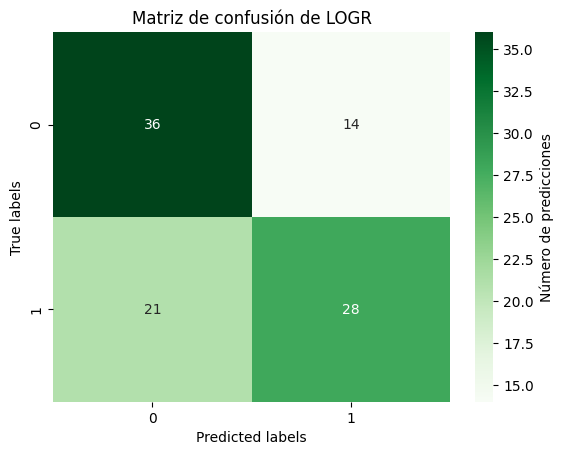

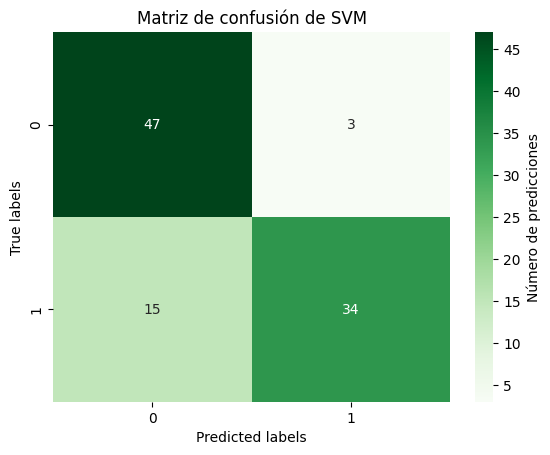

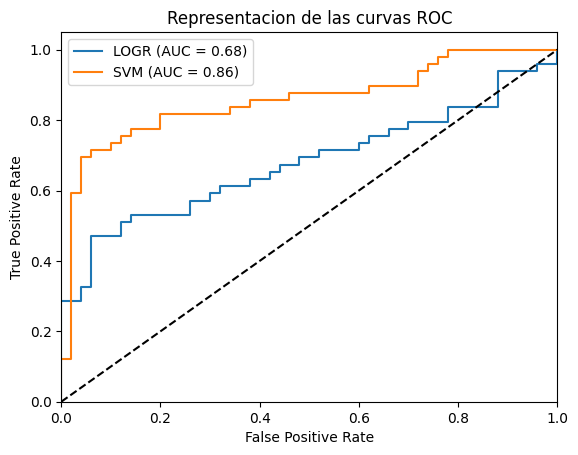

In [94]:
# Matrices de confusión
import seaborn as sns
import matplotlib.pyplot as plt

# Graficar las matrices de confusión usando seaborn con true labels y predicted labels
for nombre, y_pred in y_pred_test.items():
    plt.figure()
    sns.heatmap(metrics.confusion_matrix(y_testing, y_pred), annot=True, fmt='d', 
                cmap='Greens', cbar_kws={'label': 'Número de predicciones'})
    plt.title(f'Matriz de confusión de {nombre}')
    plt.xlabel('Predicted labels')
    plt.ylabel('True labels')
    plt.show()

# Comparacion de curvas ROC, el parametro mencionado para SVM es probability=True que ya esta en el modelo
import matplotlib.pyplot as plt
plt.figure()
for nombre, model in models.items():
    y_proba = model.predict_proba(X_test_selected)[:, 1]
    fpr, tpr, _ = metrics.roc_curve(y_testing, y_proba)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {metrics.roc_auc_score(y_testing, y_proba):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Representacion de las curvas ROC')
plt.legend(loc='upper left')
plt.show()


#### 7) Interpretación de resultados (0.5 puntos)
* Justifica brevemente cuál de los dos modelos utilizarías para ponerlo en producción

Basandome en la informacion obtenida elegiría **SVM** para ponerlo en producción ya que:

1. **SVM tiene mejor rendimiento y resultados que LOGR**:
   - Exactitud: 81.82% vs 64.65% (+17.17%)
   - Precisión: 83.77% vs 64.89% (+18.88%)
   - AUC: 0.86 vs 0.68 (+0.18)

2. **SVM presenta una alta capacidad discriminativa**: AUC de SVM (0.86) está muy cerca del umbral de excelencia (0.9), mientras que el de LOGR solo alcanza 0.68.

3. **SVM presenta buen equilibrio entre precisión y sensibilidad**: SVM mantiene un buen balance con F-Score de 81.52%, indicando que maneja bien tanto los falsos positivos como los falsos negativos.

4. **Resultados de la validación cruzada**: Durante la validación cruzada, SVM también mostró mejor exactitud media (80.93% SVM vs 71.74% LOGR) con desviación estándar similar.

La única desventaja de SVM es menor interpretabilidad comparado con LOGR, pero considerando la gran differencia en el rendimiento se justifica SVM para un entorno porductivo donde la precisión predictiva es la prioridad.





